C:\Users\suman\AppData\Local\Temp\ipykernel_32436\1612843581.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=odor_counts.head(top_n).index, y=odor_counts.head(top_n).values, palette="viridis")


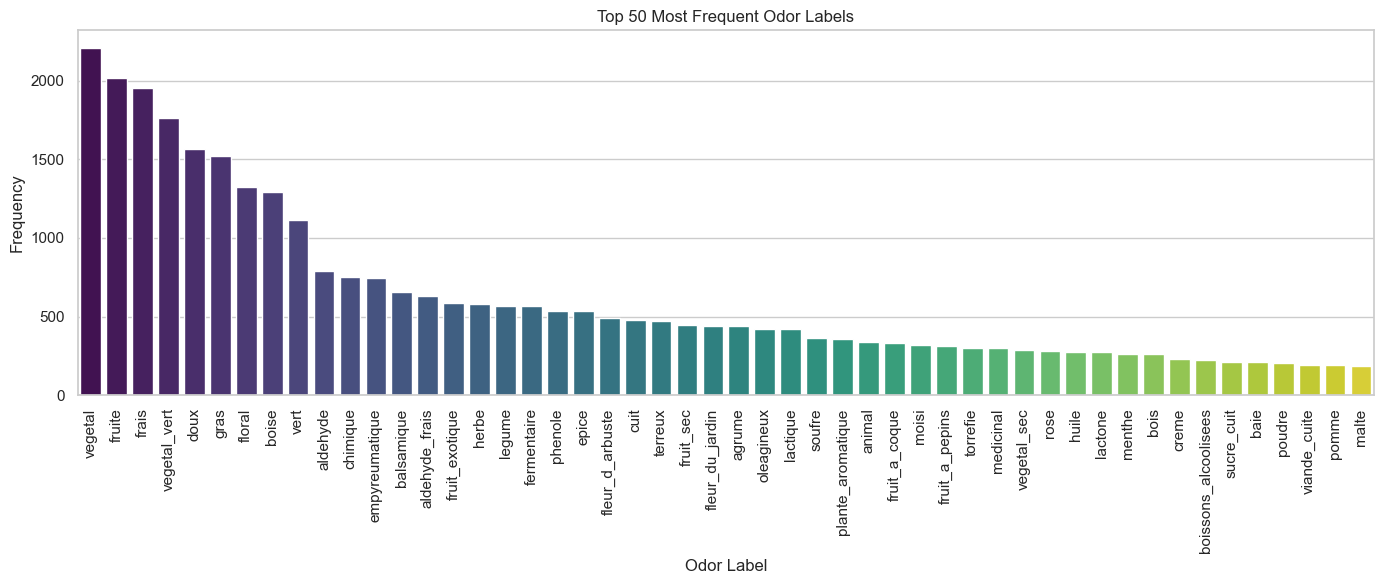

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("OdorSmiles_Updated.csv")

# Exclude identifier and SMILES columns
odor_columns = df.columns[2:]

# Count how many times each odor descriptor appears
odor_counts = df[odor_columns].sum().sort_values(ascending=False)
odor_counts2 = df[odor_columns].sum().sort_values(ascending=True)

# Set Seaborn style
sns.set(style="whitegrid")

# Plot the histogram for top 50 odor labels
plt.figure(figsize=(14, 6))
top_n = 50
sns.barplot(x=odor_counts.head(top_n).index, y=odor_counts.head(top_n).values, palette="viridis")
plt.xticks(rotation=90)
plt.title(f"Top {top_n} Most Frequent Odor Labels")
plt.ylabel("Frequency")
plt.xlabel("Odor Label")
plt.tight_layout()
plt.show()

<Figure size 1600x800 with 0 Axes>

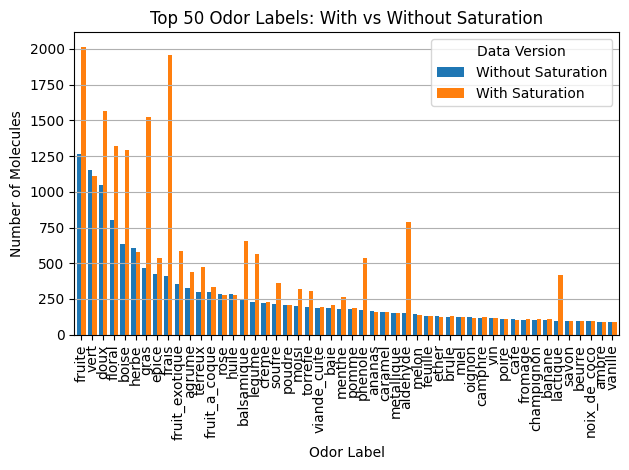

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load both datasets
df_no_sat = pd.read_csv("Without_Saturation_CAS_SMILES.csv")  # Without saturation
df_sat = pd.read_csv("OdorSmiles_Updated.csv")   # With saturation

# Exclude identifier and SMILES columns
odor_columns = df_no_sat.columns[2:]

odor_columns_no_sat = df_no_sat.columns.difference(["cas_number", "SMILES"])
odor_columns_sat = df_sat.columns.difference(["cas_number", "SMILES"])

# Combine into a single DataFrame for plotting
odor_comparison = pd.DataFrame({
    "Without Saturation": odor_counts_no_sat,
    "With Saturation": odor_counts_sat
}).sort_values("Without Saturation", ascending=False)

# Plotting
plt.figure(figsize=(16, 8))
odor_comparison.head(50).plot(kind='bar', width=0.8)
plt.title("Top 50 Odor Labels: With vs Without Saturation")
plt.ylabel("Number of Molecules")
plt.xlabel("Odor Label")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title="Data Version")
plt.show()



In [20]:
def imbalance_metrics(counts, label=""):
    max_count = counts.max()
    min_count = counts[counts > 0].min()
    ratio = max_count / min_count if min_count > 0 else float("inf")
    print(f"--- {label} ---")
    print(f"Total Labels: {len(counts)}")
    print(f"Max Count: {max_count}")
    print(f"Min Count (non-zero): {min_count}")
    print(f"Imbalance Ratio (Max/Min): {ratio:.2f}")
    print(f"Mean: {counts.mean():.2f}")
    print(f"Std Dev: {counts.std():.2f}")
    print()

imbalance_metrics(df_no_sat[odor_columns_no_sat].sum(), "Without Saturation")
imbalance_metrics(df_sat[odor_columns_sat].sum(), "With Saturation")


--- Without Saturation ---
Total Labels: 394
Max Count: 1220
Min Count (non-zero): 1
Imbalance Ratio (Max/Min): 1220.00
Mean: 49.99
Std Dev: 126.15

--- With Saturation ---
Total Labels: 436
Max Count: 2210
Min Count (non-zero): 1
Imbalance Ratio (Max/Min): 2210.00
Mean: 97.97
Std Dev: 261.82



In [15]:
# Count total odor descriptor columns (excluding cas_number and SMILES)
odor_columns_no_sat = df_no_sat.columns[2:]
odor_columns_sat = df_sat.columns[2:]

print("Odor Descriptors WITHOUT Saturation:", len(odor_columns_no_sat))
print("Odor Descriptors WITH Saturation:", len(odor_columns_sat))


Odor Descriptors WITHOUT Saturation: 393
Odor Descriptors WITH Saturation: 436
